**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Tutorial 3
## Predicting Bike Sharing Usage

In this tutorial you will train a regression function to predict the number people using bike sharing in each day.

First we need to initialize Python.  Run the below cell.

In [2]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
import glob
import os
import csv
import string
random.seed(100)
import pandas as pd
import xgboost as xgb
from scipy import stats

## Loading Data and Pre-processing
Next we need to load the data.  Download `Bike-Sharing-Dataset.zip`, and **unzip** it in the same directory as this ipynb file.  Then run the following cell to load the data.

In [4]:
# read the data
filename = 'Bike-Sharing-Dataset/day.csv'
df = pd.read_csv(filename)
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


Here are the columns in the dataset. The last 3 columns are the counts for the day.

In [5]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Here is a description of the features:
- `instant`: record index
- `dteday`: date
- `season`: season (1: winter, 2:spring, 3:summer, 4:fall)
- `yr`: year (0: 2011, 1:2012)
- `mnth`: month (1=Jan to 12=Dec)
- `holiday`: weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- `weekday`: day of the week (1=Sunday to 7=Saturday)
- `workingday`: if day is neither weekend nor holiday is 1, otherwise is 0.
- `weathersit`: weather situation
  - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
  - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
- `temp`: Normalized temperature in Celsius. The values are divided to 41 (max)
- `atemp`: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- `hum`: Normalized humidity. The values are divided to 100 (max)
- `windspeed`: Normalized wind speed. The values are divided to 67 (max)
- `casual`: count of casual users
- `registered`: count of registered users
- `cnt`: count of total rental bikes including both casual and registered

The first two columns are the instance number and date, which aren't useful, so we will remove them.

In [6]:
# remove first 2 columns
df.drop(columns=['instant', 'dteday'], inplace=True)

Next we will examine the distribution of the features.

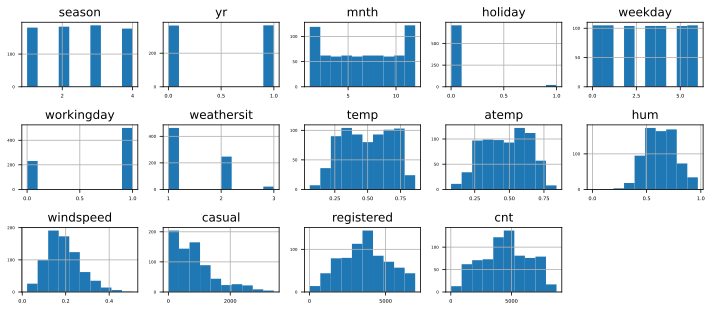

In [7]:
# show the feature distributions
foo = df.hist(layout=(14,5), figsize=(10,20), xlabelsize=5, ylabelsize=4)
plt.tight_layout()

And here are some simple statistics of the features.

In [8]:
df.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


You may notice that a few of the features are discrete values, such as `season`, `mnth`, `weekday`, and `weathersit`.  If we directly use the month feature, it may not make too much sense since adding/subtracting/multipllying 2 month numbers doesn't really mean anything related to the output. Instead, it is important which month it is.

Thus, we will convert these features into one-hot-encodings.  The original discrete features are removed, and the new features are appended to the end of the table.

In [9]:
# use pandas to create one-hot-encodings of a few colummns
dfd = pd.get_dummies(df, columns=['season', 'mnth', 'weekday', 'weathersit'])
dfd

,yr,holiday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,...,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3
0,0,0,0,0.344167,0.363625,0.805833,0.160446,331,654,985,...,False,False,False,False,False,False,True,False,True,False
1,0,0,0,0.363478,0.353739,0.696087,0.248539,131,670,801,...,True,False,False,False,False,False,False,False,True,False
2,0,0,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,...,False,True,False,False,False,False,False,True,False,False
3,0,0,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,...,False,False,True,False,False,False,False,True,False,False
4,0,0,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,0,1,0.254167,0.226642,0.652917,0.350133,247,1867,2114,...,False,False,False,False,True,False,False,False,True,False
727,1,0,1,0.253333,0.255046,0.590000,0.155471,644,2451,3095,...,False,False,False,False,False,True,False,False,True,False
728,1,0,0,0.253333,0.242400,0.752917,0.124383,159,1182,1341,...,False,False,False,False,False,False,True,False,True,False
729,1,0,0,0.255833,0.231700,0.483333,0.350754,364,1432,1796,...,True,False,False,False,False,False,False,True,False,False


Now we extract the data for running our regression algorithm. First we remove the counts to get the input features X.

In [10]:
# extract the features
dfX = dfd.drop(columns=['casual', 'registered', 'cnt'])
dataX = array(dfX)
dataX.shape

(731, 33)

In [11]:
# get the feature names
featnames = [x.strip() for x in dfX.columns]
print(featnames)

['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'season_1', 'season_2', 'season_3', 'season_4', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_1', 'weathersit_2', 'weathersit_3']


Next we use the total count as the target Y.

In [12]:
# get the target count
dataY = array(dfd['cnt'])
dataY.shape

(731,)

Finally, we extract the year number, which we will use for setting up the training/testing data later.

In [13]:
# get the year number (used for splitting the data into training/testing)
dataYear = array(dfd['yr'])
dataYear.shape

(731,)

Here is an example input/output for our problem.

In [14]:
print(featnames)

print("--- example features---")
print(dataX[0])
print("--- example target count")
print(dataY[0])

['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'season_1', 'season_2', 'season_3', 'season_4', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_1', 'weathersit_2', 'weathersit_3']
--- example features---
[0 0 0 0.344167 0.363625 0.805833 0.160446 True False False False True
 False False False False False False False False False False False False
 False False False False False True False True False]
--- example target count
985


Now we separate the data into training and testing sets.  Since our data is collected over time, it is better to separate the training and test data so that they don't overlap in time. This way, we can ensure that our method generalizes to newly collected data.

We will use the first year for training, and the second year for testing.

In [15]:
# use 1st year as training data
trainX = dataX[dataYear==0]
trainY = dataY[dataYear==0]
# use 2nd year as testing data
testX  = dataX[dataYear==1]
testY  = dataY[dataYear==1]

print(trainX.shape)
print(testX.shape)

(365, 33)
(366, 33)


Note that the input features are already normalized between 0 and 1 (or are binary values), so we don't need to perform feature normalization.

### Dummy regressor
We next test a "dummy" regressor that simply predicts the mean or median output value.  These are useful to evaluate the regression methods to see how much better they are than simply predicting the same value.

In [16]:
# dummy regressors that predict constant values
dummy_mean = dummy.DummyRegressor(strategy='mean')
dummy_mean.fit(trainX, trainY)
dummy_med  = dummy.DummyRegressor(strategy='median')
dummy_med.fit(trainX, trainY)

,strategy,'median'
,constant,None
,quantile,None


Next we evaluate the regressor using MSE and MAE.

In [17]:
# function to evaluate root mean squared error (MSE) and mean absolute error (MAE)
def eval_predict(trueY, predY):
    MAE = metrics.mean_absolute_error(trueY, predY)
    RMSE = sqrt(metrics.mean_squared_error(trueY, predY))
    return RMSE, MAE

# function to make a scatter plot
def plot_scatter(testY, predY, titlestr):
    plt.scatter(testY, predY, s=1)
    plt.plot([min(testY),max(testY)], [min(testY),max(testY)], 'r-')
    plt.xlabel('true')
    plt.ylabel('prediction')
    r1,r2 = eval_predict(testY, predY)
    plt.title(titlestr + "\n(RMSE={:.3f}; MAE={:.3f})".format(r1,r2))
    plt.grid(True)

In [18]:
# place to store our regression results
trainerr={}; testerr={}

trainerr['dummy_mean'] = eval_predict(trainY, dummy_mean.predict(trainX))
testerr['dummy_mean']  = eval_predict(testY, dummy_mean.predict(testX))
trainerr['dummy_med']  = eval_predict(trainY, dummy_med.predict(trainX))
testerr['dummy_med']   = eval_predict(testY, dummy_med.predict(testX))

print("dummy-mean: train (RMSE,MAE)=", trainerr['dummy_mean'] )
print("dummy-mean: test  (RMSE,MAE)=", testerr['dummy_mean']  )
print("dummy-med:  train (RMSE,MAE)=", trainerr['dummy_med']  )
print("dummy-med:  test  (RMSE,MAE)=", testerr['dummy_med']   )

dummy-mean: train (RMSE,MAE)= (np.float64(1376.8636667749531), 1197.7539801088385)
dummy-mean: test  (RMSE,MAE)= (np.float64(2829.3083242385123), 2488.6733587843405)
dummy-med:  train (RMSE,MAE)= (np.float64(1416.8517338156587), 1172.8849315068494)
dummy-med:  test  (RMSE,MAE)= (np.float64(2578.749205425156), 2260.841530054645)


Finally, we can visualize the quality of the prediction result by using a scatter plot of truth vs. prediction.  Since we are using a "dummy" predictor, the x-value predictions are constant.  The red line shows the ideal regressor where all the predictions are equal to the true values.

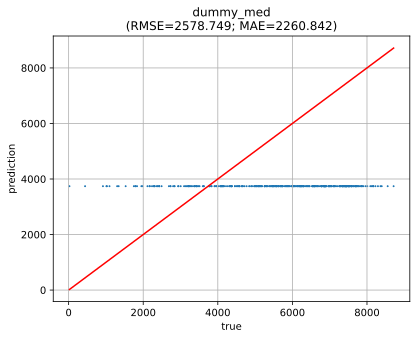

In [19]:
plot_scatter(testY, dummy_med.predict(testX), 'dummy_med')

## Prediction with Linear Regression

First we will look at predicting the count using simple linear regression models.  Use the training data to fit a linear model using Ordinary Least Squares and Ridge Regression.  Use cross-validation on the training set to select the optimal $\alpha$ parameter for ridge regression.

OLS: train (RMSE,MAE)= (np.float64(549.2811066744396), 407.40419100694726)
OLS: test  (RMSE,MAE)= (np.float64(2298.932467514501), 2121.7649628987638)
RR: train (RMSE,MAE)= (np.float64(551.4275499046495), 407.60044889803436)
RR: test  (RMSE,MAE)= (np.float64(2315.977221231905), 2137.381892879455)


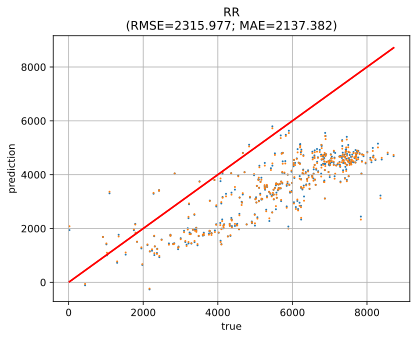

In [29]:
### INSERT YOUR CODE HERE
ols = linear_model.LinearRegression().fit(trainX, trainY)
rr = linear_model.RidgeCV(alphas=logspace(-3,3,50)).fit(trainX, trainY)

ols_pred = ols.predict(testX)
ridge_pred = rr.predict(testX)

for name, yhat in [('OLS', ols_pred), ('RR', ridge_pred)]:
    trainerr[name] = eval_predict(trainY, ols.predict(trainX) if name=='OLS' else rr.predict(trainX))
    testerr[name]  = eval_predict(testY, yhat)
    print(f"{name}: train (RMSE,MAE)=", trainerr[name] )
    print(f"{name}: test  (RMSE,MAE)=", testerr[name]  )
    plot_scatter(testY, yhat, name)

Compare the two models using the RMSE and MAE between the predictions and the true values.  Below is  code that will calculate evaluation for the training and test sets.

In [30]:
# ols is the linear regression model
trainerr['ols'] = eval_predict(trainY, ols.predict(trainX))
testerr['ols']  = eval_predict(testY, ols.predict(testX))
print("OLS: train MSE,MAE =", trainerr['ols'])
print("OLS: test  MSE,MAE =", testerr['ols'])

# rr is the ridge regression model
trainerr['rr'] = eval_predict(trainY, rr.predict(trainX))
testerr['rr']  = eval_predict(testY, rr.predict(testX))
print("RR: train MSE,MAE =", trainerr['rr'])
print("RR: test  MSE,MAE =", testerr['rr'])

OLS: train MSE,MAE = (np.float64(549.2811066744396), 407.40419100694726)
OLS: test  MSE,MAE = (np.float64(2298.932467514501), 2121.7649628987638)
RR: train MSE,MAE = (np.float64(551.4275499046495), 407.60044889803436)
RR: test  MSE,MAE = (np.float64(2315.977221231905), 2137.381892879455)


Which model has better prediction ability on the test set? Why?
- **INSERT YOUR ANSWER HERE**
- The OLS model has slightly better prediction ability on the test set, because its RMSE (2298.93) and MAE (2121.76) are both lower than those of the Ridge model (RMSE = 2315.98, 2137.38).

Finally, we look at the scatter plot for ridge-regression.

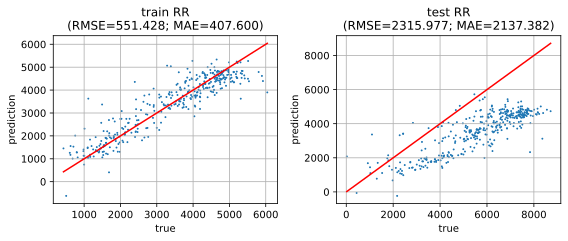

In [31]:
# rr is the ridge regression model
plt.figure(figsize=(8,3.5))
plt.subplot(1,2,1)
plot_scatter(trainY, rr.predict(trainX), "train RR")
plt.subplot(1,2,2)
plot_scatter(testY, rr.predict(testX), "test RR")
plt.tight_layout()

Do you notice anything interesting about the test predictions?  We'll see how to solve this problem later.

- **INSERT YOUR ANSWER HERE**
- The scatter plot of the test set show that the ridge regression model tends to underestimate high rental counts. In general, the predictions are lower than what is the true value; and the underestimation gap is larger when the true value is large.

# Which features are important?
Next we will investigate which features are the most important for the prediction.  Use LASSO with cross-validation to learn the model.

In [34]:
### INSERT YOUR CODE HERE
lasso_pipe = pipeline.make_pipeline(preprocessing.StandardScaler(), linear_model.LassoCV(cv=5, alphas=logspace(-3,3,50)))
lasso_pipe.fit(trainX, trainY)

las = lasso_pipe.named_steps['lassocv']
alpha_star = las.alpha_
coef = pd.Series(las.coef_, index=featnames)

print(f"Best alpha: {alpha_star: .5g}")
print(f"Number of non-zero features: {(coef!=0).sum()} out of {len(coef)}")

Best alpha:  19.307
Number of non-zero features: 20 out of 33


In [39]:
imp = coef[coef != 0].sort_values(key=lambda x: x.abs(), ascending=False)

K = 10
top_pos = imp[imp > 0][:K]
top_neg = imp[imp < 0][:K]

print(f"Positives")
display(pd.DataFrame({"feature": top_pos.index, "coef": top_pos.values}))
print(f"Negatives")
display(pd.DataFrame({"feature": top_neg.index, "coef": top_neg.values}))

pred_test = lasso_pipe.predict(testX)
rmse = metrics.root_mean_squared_error(testY, pred_test)
mae = metrics.mean_absolute_error(testY, pred_test)
print(f"Lasso test RMSE: {rmse:.3f}, MAE: {mae:.3f}")

Positives


,feature,coef
0,temp,634.262556
1,mnth_5,170.214290
2,weathersit_1,145.249631
3,mnth_6,116.389340
4,season_4,114.503113
5,mnth_9,109.584162
6,mnth_10,92.958784
7,season_3,9.761431
8,weekday_5,1.103385


Negatives


,feature,coef
0,season_1,-374.132733
1,weathersit_3,-254.326391
2,hum,-149.426458
3,windspeed,-139.797899
4,mnth_1,-113.068582
5,mnth_2,-64.017178
6,mnth_3,-59.469640
7,holiday,-43.957082
8,season_2,-38.862401
9,weekday_0,-18.860418


Lasso test RMSE: 2306.765, MAE: 2126.336


Examine the LASSO coefficients by sorting them in descending order.

In [40]:
# las is the trained LASSO model
# sort coefficients from smallest to largest, then reverse it
inds = argsort(abs(las.coef_))[::-1]
# print out
print("weight : feature description")
for i in inds:
    print("{: .3f} : {}".format(las.coef_[i], featnames[i]))
print("bias = ", las.intercept_)

weight : feature description
 634.263 : temp
-374.133 : season_1
-254.326 : weathersit_3
 170.214 : mnth_5
-149.426 : hum
 145.250 : weathersit_1
-139.798 : windspeed
 116.389 : mnth_6
 114.503 : season_4
-113.069 : mnth_1
 109.584 : mnth_9
 92.959 : mnth_10
-64.017 : mnth_2
-59.470 : mnth_3
-43.957 : holiday
-38.862 : season_2
-18.860 : weekday_0
 9.761 : season_3
-6.459 : mnth_7
 1.103 : weekday_5
 0.000 : mnth_8
-0.000 : weekday_4
-0.000 : weekday_3
 0.000 : weekday_2
-0.000 : weekday_1
-0.000 : weathersit_2
 0.000 : mnth_11
-0.000 : mnth_12
 0.000 : weekday_6
-0.000 : mnth_4
 0.000 : atemp
 0.000 : workingday
 0.000 : yr
bias =  3405.7616438356176


_Which features have largest affect on the predicted bike share count, and what is the interpretation?_

Note that the features are normalized between 0 and 1 (or are binary values), so the weights corresponding to increase/decrease of bike count.  The bias term corresponds to the typical number of bikes used, which is modified based on the features.
- **INSERT YOUR ANSWER HERE**
1. The most influential features are temperature, season, weather, month, and humidity.
2. A high positive coefficient for temp (634.263) indicates that warmer weather strongly increases the number of bike rentals.
3. Negative coefficients such as season_1 (winter), weathersit_3 (light snow/rain), and humidity show that cold or unfavorable conditions reduce bike usage.
4. A high positive feature is mnth_5 (May), which indicates this month can see a positive increase of the bike rentals, possibly due to the fact that May is a favorable time for biking.

Now try feature selection using OMP.  You can try the top 10 features.

In [45]:
### INSERT YOUR CODE HERE
omp_pipe = pipeline.make_pipeline(preprocessing.StandardScaler(with_mean=False), linear_model.OrthogonalMatchingPursuit(n_nonzero_coefs=10))
omp_pipe.fit(trainX, trainY)

omp = omp_pipe.named_steps['orthogonalmatchingpursuit']
coef = pd.Series(omp.coef_, index=featnames)
selected = coef[coef != 0].sort_values(key=lambda x: x.abs(), ascending=False)

print("Selected features and their coefficients:")
display(pd.DataFrame({"feature": selected.index, "coef": selected.values}))

pred_test = omp_pipe.predict(testX)
rmse = metrics.root_mean_squared_error(testY, pred_test)
mae = metrics.mean_absolute_error(testY, pred_test)
print(f"OMP test RMSE: {rmse:.3f}, MAE: {mae:.3f}")

Selected features and their coefficients:


,feature,coef
0,atemp,737.923160
1,season_1,-390.202431
2,weathersit_3,-317.914605
3,season_4,250.314366
4,mnth_5,192.937299
5,hum,-188.391338
6,mnth_9,156.395223
7,weathersit_2,-142.369143
8,mnth_6,135.009796
9,windspeed,-133.865290


OMP test RMSE: 2289.031, MAE: 2103.665


Do you get similar selected features? Why or why not?
- **INSERT YOUR ANSWER HERE**
- Compared to LASSO, the selected features are similar in general (e.g., temperature, weather, and season-related variables) but not identical. The difference occurs because OMP uses a greedy forward-selection procedure that may favor slightly different correlated variables, while LASSO uses global L1 regularization to distribute weights more smoothly

# Non-linear Regression
Now use non-linear regression to try to improve the prediction accuracy.  Use cross-validation on the training set to select the parameters. 

In [56]:
### INSERT YOUR CODE HERE
import numpy as np
models = {
    "DecisionTree": (tree.DecisionTreeRegressor(), {'max_depth': [3, 5, 10, 15, 20, 25, 30], "min_samples_split": [2, 5, 10]}),
    "RandomForest": (ensemble.RandomForestRegressor(), {'n_estimators': [50, 100, 200, 300], 'max_depth': [5, 10, 20, 30]}),
    "SVR": (svm.SVR(), {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}),
    }

resutls = {}
best_rmse = np.inf
bestr = None

for name, (model, params) in models.items():
    pipe = pipeline.make_pipeline(preprocessing.StandardScaler(with_mean=False), model_selection.GridSearchCV(model, params, cv=5, scoring='neg_root_mean_squared_error'))
    pipe.fit(trainX, trainY)
    best_model = pipe.named_steps['gridsearchcv'].best_estimator_
    pred_test = best_model.predict(testX)
    rmse = metrics.root_mean_squared_error(testY, pred_test)
    mae = metrics.mean_absolute_error(testY, pred_test)
    resutls[name] = (rmse, mae)
    print(f"{name}: test RMSE={rmse:.3f}, MAE={mae:.3f}")
    if rmse < best_rmse:
        best_rmse = rmse
        bestr = best_model
print(f"Best model is {bestr} with RMSE={best_rmse:.3f}")

DecisionTree: test RMSE=3644.654, MAE=3276.230
RandomForest: test RMSE=4200.109, MAE=3842.624
SVR: test RMSE=2695.339, MAE=2368.039
Best model is SVR(C=10) with RMSE=2695.339


Make a scatter plot of the best regressor. Call it `bestr`.

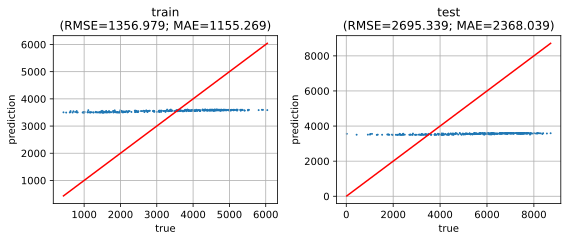

In [57]:
# scatter plot of the best regressor (bestr)
plt.figure(figsize=(8,3.5))
plt.subplot(1,2,1)
plot_scatter(trainY, bestr.predict(trainX), "train")
plt.subplot(1,2,2)
plot_scatter(testY, bestr.predict(testX), "test")
plt.tight_layout()

_Which regression method performs the best? Why do you think so?_
- **INSERT YOUR ANSWER HERE**
1. We can observe that the performance of non-linear models such as Decision Tree, Random Forest, and SVR were worse than that of the linear models.
2. This is likely because the dataset mainly exhibits linear relationships between features (e.g., temperature, himidity, etc.) and the target variable, while non-linear models introduce unnecessary complexity and overfit noise.

# Test set bias

In your scatter plot above, you may have noticed that the regressor is almost always under-predicting the count (the points are usually below the red line). This suggests that there is some bias in the test set.

Let's look at the plot of the count over time.  The left side is the training data (1st year), and the right side is the testing data (2nd year)

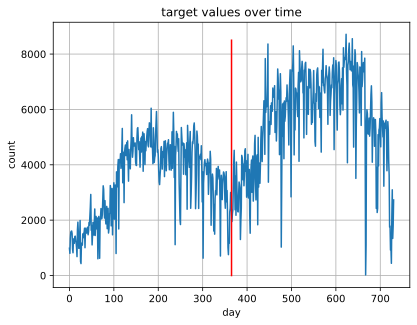

In [58]:
plt.plot(dataY)
plt.plot([365,365], [0,8500], 'r')
plt.grid(True)
plt.xlabel('day')
plt.ylabel('count')
plt.title('target values over time');

Interestingly, it looks like bike sharing became more popular in the 2nd year, so the overall counts are higher (but the seasonal trend looks the same).

Let's assume that we noticed this upward trend in the first 3 months of the year, and collected the data for training.  We will then use the remaining part of the 2nd year for testing.

In [59]:
# get indices for month 1 to month 3
print(featnames[11], featnames[12], featnames[13])
inds = (testX[:,11].ravel()==1) + (testX[:,12].ravel()==1) + (testX[:,13].ravel()==1)

# new training data from 2nd year (months 1-3)
trainX2 = testX[inds]
trainY2  = testY[inds]
# new testing data from 2nd year (months 4-12)
testX2  = testX[logical_not(inds)]
testY2   = testY[logical_not(inds)]
print(trainX2.shape)
print(testX2.shape)

mnth_1 mnth_2 mnth_3
(91, 33)
(275, 33)


There are several approaches for using the new data:
1. use the new data to train the regressor, and ignore the old data.
2. append the new data with the old data and train a regressor.  Note that we kept the "year" feature, so the regressor can distinguish the new and old training data.
3. use the new data to train a regressor on the residual error of the old regressor.  The residual error is the difference between the predicted count and true count on the new training data.

Using **one selected** regression method, try each of the approaches above to use the new data. You should compare the 3 approaches with the regressor trained on the original data and tested on the new test set (`testY2`).

In [60]:
# append new data with old data
trainY2_append = concatenate((trainY, trainY2), axis=0)
trainX2_append = concatenate((trainX, trainX2), axis=0)
print(trainY2_append.shape)
print(trainX2_append.shape)

(456,)
(456, 33)


In [61]:
### INSERT YOUR CODE HERE
reg = linear_model.RidgeCV(alphas=logspace(-3,3,50))
results = {}

reg.fit(trainX2, trainY2)
pred_1 = reg.predict(testX2)
rmse_1 = metrics.root_mean_squared_error(testY2, pred_1)
mae_1 = metrics.mean_absolute_error(testY2, pred_1)
results['Only New Data'] = (rmse_1, mae_1)

reg.fit(trainX2_append, trainY2_append)
pred_2 = reg.predict(testX2)
rmse_2 = metrics.root_mean_squared_error(testY2, pred_2)
mae_2 = metrics.mean_absolute_error(testY2, pred_2)
results['Old + New Data'] = (rmse_2, mae_2)

reg.fit(trainX, trainY)
residual = trainY2 - reg.predict(trainX2)

residual_model = linear_model.RidgeCV(alphas=logspace(-3,3,50))
residual_model.fit(trainX2, residual)

pred_3 = reg.predict(testX2) + residual_model.predict(testX2)
rmse_3 = metrics.root_mean_squared_error(testY2, pred_3)
mae_3 = metrics.mean_absolute_error(testY2, pred_3)
results['Residual Model'] = (rmse_3, mae_3)

for name, (rmse, mae) in results.items():
    print(f"{name}: test RMSE={rmse:.3f}, MAE={mae:.3f}")


Only New Data: test RMSE=1224.475, MAE=981.757
Old + New Data: test RMSE=1043.392, MAE=816.905
Residual Model: test RMSE=1585.197, MAE=1193.125


_Which approach for using the new data is better? Explain why you think the other approaches don't work well._
- **INSERT YOUR ANSWER HERE**
  1. Appending the new data to the old training data performs the best. This approach allows the model to retain the long-term seasonal patterns and relationships between weather and bike usage learned from the first year while adapting to the higher overall demand in the second year.
  2. In contrast, using only the new data provides too few samples and risks overfitting. The resudial correction is less stable because residuals contain random noise and are difficult to model accurately.